# ATLAS SENTINEL — Análisis exploratorio de delitos en CABA

**Qué es esto y por qué llega tarde.** El proyecto entró directo a construir la grilla H3
y entrenar. La calidad de los datos se auditó a fondo (encodings, sistemas de coordenadas,
esquemas que cambian entre años) y hay estadística descriptiva desperdigada por el
repositorio, pero siempre como justificación de una decisión ya tomada: *"82,8% de ceros,
por eso Tweedie"*. Nunca se miró el fenómeno por sí mismo.

Este notebook responde cinco preguntas que un EDA hecho a tiempo habría contestado antes
de entrenar nada. Tres de las respuestas explican resultados que hasta ahora estaban solo
observados.

| # | Pregunta | Por qué importa |
|---|---|---|
| 1 | ¿Cómo se mueve el volumen en 10 años? | La pandemia está adentro del set de entrenamiento |
| 2 | ¿Qué ciclos temporales hay? | Define cuánto puede aportar el calendario |
| 3 | ¿La mezcla de tipos es estable? | Un modelo agregado entrenado en un régimen predice otro |
| 4 | ¿El riesgo se concentra espacialmente? | Es la premisa central del proyecto, nunca medida |
| 5 | ¿El mapa de un año predice el del siguiente? | Es el techo contra el que compite el modelo |

**Fuente**: `data/features/delitos_hex.parquet` — 1.353.136 delitos georreferenciados
(2016-2025), ya cruzados contra la grilla H3-8. Una fila es un delito, el mismo criterio
que usa `build_training_table.py`, para que los números sean comparables con los del modelo.

In [1]:
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.collections import PolyCollection
from shapely import wkt

RAIZ = Path.cwd().parent
sys.path.insert(0, str(RAIZ / "src" / "validation"))

from eda_delitos import (
    cargar_delitos, matriz_vecindad, morans_i, morans_local, DIAS,
)

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "600",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "figure.facecolor": "white", "axes.facecolor": "white",
})
TINTA, ACENTO, ALERTA = "#1f2933", "#2563eb", "#c2410c"

d = cargar_delitos()
print(f"{len(d):,} delitos | {d.anio.min()}-{d.anio.max()} | "
      f"{d.hex_id.nunique()} hexágonos | {d.tipo.nunique()} tipos")
d.head()

1,353,136 delitos | 2016-2025 | 575 hexágonos | 6 tipos


,fecha,hex_id,turno,tipo,anio,mes,dia_semana
0,2016-01-26,88c2e38da5fffff,Tarde,Robo,2016,1,1
1,2016-01-20,88c2e38da5fffff,Tarde,Robo,2016,1,2
2,2016-01-03,88c2e38d33fffff,Mañana,Robo,2016,1,6
3,2016-01-09,88c2e38d33fffff,Tarde,Robo,2016,1,5
4,2016-01-25,88c2e38d33fffff,Tarde,Robo,2016,1,0


---
## 1. Nivel y quiebres

El modelo entrena con 2016-2023, valida con 2024 y testea con 2025. La cuarentena de 2020
—una de las más largas del mundo— cae **dentro del set de entrenamiento**. La pregunta es
si dejó un quiebre estructural o si el nivel volvió.

findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


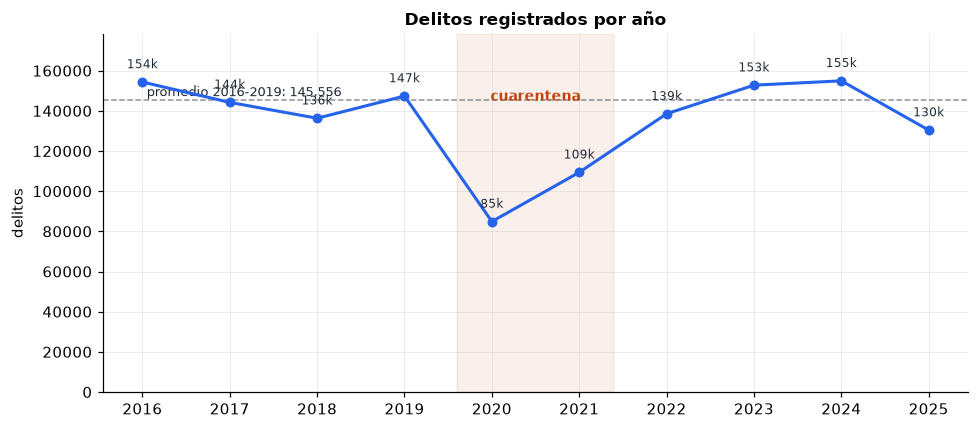

2016-2019:   145,556
2022-2025:   144,163   (-1.0%)


In [2]:
por_anio = d.groupby("anio").size()
base = por_anio.loc[2016:2019].mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.axvspan(2019.6, 2021.4, color=ALERTA, alpha=0.08, zorder=0)
ax.text(2020.5, por_anio.max() * 0.97, "cuarentena", ha="center", va="top",
        fontsize=9, color=ALERTA, weight="600")
ax.axhline(base, color=TINTA, ls="--", lw=1, alpha=0.5)
ax.text(2016.05, base * 1.012, f"promedio 2016-2019: {base:,.0f}", fontsize=8.5, color=TINTA)
ax.plot(por_anio.index, por_anio.values, "-o", color=ACENTO, lw=2, ms=5.5, zorder=3)
for a, v in por_anio.items():
    ax.annotate(f"{v/1000:.0f}k", (a, v), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=8, color=TINTA)
ax.set_title("Delitos registrados por año")
ax.set_ylabel("delitos"); ax.set_xlabel(""); ax.set_ylim(0, por_anio.max() * 1.15)
ax.set_xticks(por_anio.index)
plt.tight_layout(); plt.show()

post = por_anio.loc[2022:2025].mean()
print(f"2016-2019: {base:>9,.0f}")
print(f"2022-2025: {post:>9,.0f}   ({post/base - 1:+.1%})")

**El pozo es profundo pero transitorio.** 2020 cae 42% y 2021 sigue 25% abajo, pero el
promedio 2022-2025 queda a **1% del promedio prepandemia**. No hay quiebre de nivel que
invalide entrenar con la serie completa.

Vale anotar que 2025 —el año de test— cierra 10% por debajo del nivel prepandemia y 16%
por debajo de 2024, con los doce meses completos. Es una caída real, no datos truncados.
Se retoma en el punto 3.

---
## 2. Estacionalidad: ¿dónde está el ciclo temporal?

El modelo tiene features de calendario (día de semana, mes, feriado) y se le sumó clima,
que no aportó nada. Conviene ver cuánta amplitud tiene realmente cada ciclo.

Se mide sobre 2022-2025 para no mezclar el régimen de cuarentena, que tenía un patrón
semanal completamente distinto por restricción de circulación.

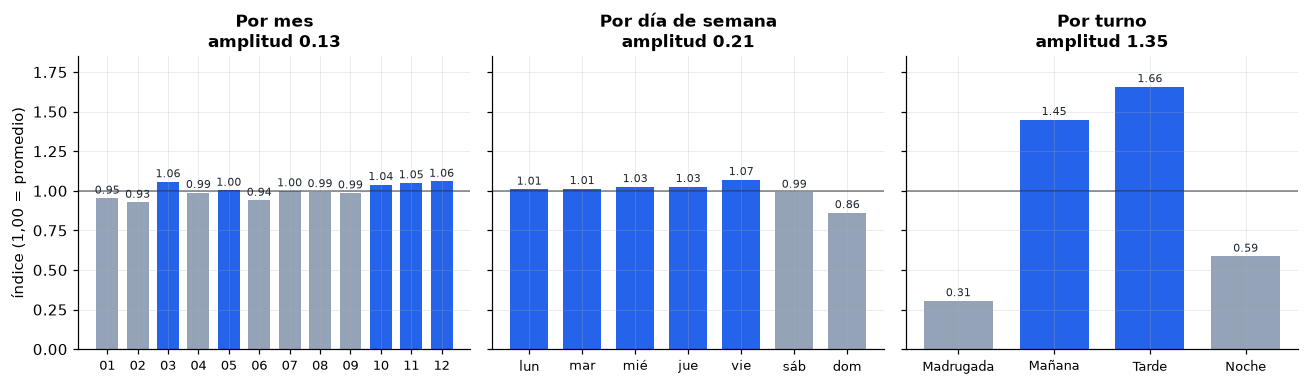

In [3]:
r = d[d.anio >= 2022]
indice = lambda s: s / s.mean()

por_mes = indice(r.groupby("mes").size())
por_dia = indice(r.groupby("dia_semana").size())
por_turno = indice(r.groupby("turno").size()).reindex(["Madrugada", "Mañana", "Tarde", "Noche"])

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
paneles = [
    (axes[0], por_mes, [f"{m:02d}" for m in por_mes.index], "Por mes"),
    (axes[1], por_dia, [n[:3] for n in DIAS], "Por día de semana"),
    (axes[2], por_turno, list(por_turno.index), "Por turno"),
]
for ax, serie, etiquetas, titulo in paneles:
    amp = serie.max() - serie.min()
    colores = [ACENTO if v >= 1 else "#94a3b8" for v in serie.values]
    ax.bar(range(len(serie)), serie.values, color=colores, width=0.72)
    ax.axhline(1, color=TINTA, lw=1, alpha=0.6)
    ax.set_xticks(range(len(serie))); ax.set_xticklabels(etiquetas, fontsize=8.5)
    ax.set_title(f"{titulo}\namplitud {amp:.2f}")
axes[0].set_ylabel("índice (1,00 = promedio)")
axes[0].set_ylim(0, 1.85)
for ax, serie, *_ in paneles:
    for i, v in enumerate(serie.values):
        ax.annotate(f"{v:.2f}", (i, v), textcoords="offset points", xytext=(0, 3),
                    ha="center", fontsize=7.5, color=TINTA)
plt.tight_layout(); plt.show()

**Todo el ciclo temporal está en el turno, y el turno ya es una dimensión de la grilla.**

La Tarde tiene **5,4 veces** los delitos de la Madrugada (1,66 contra 0,31). Entre el mes
más y el menos delictivo hay 13%, y entre el día más y el menos, 21% — y ese 21% es casi
todo el domingo, el único día que se despega.

Como el modelo trabaja a grano hex × día × turno, el ciclo dominante **ya está codificado
en la estructura del problema**: no es algo que el modelo tenga que descubrir. Al calendario
le queda por explicar la diferencia entre un martes y un jueves, que es ruido.

Es la razón estructural de que `dia_semana` y `mes` aporten poco, y de que sumar clima —que
actúa a escala de día, no de turno— no moviera ninguna métrica.

---
## 3. Composición por tipo: ¿el modelo agregado predice lo mismo que entrenó?

El modelo núcleo suma los seis tipos en un solo target. Eso es válido mientras la mezcla
sea estable; si cambia, el modelo entrenado en un régimen está prediciendo otro.

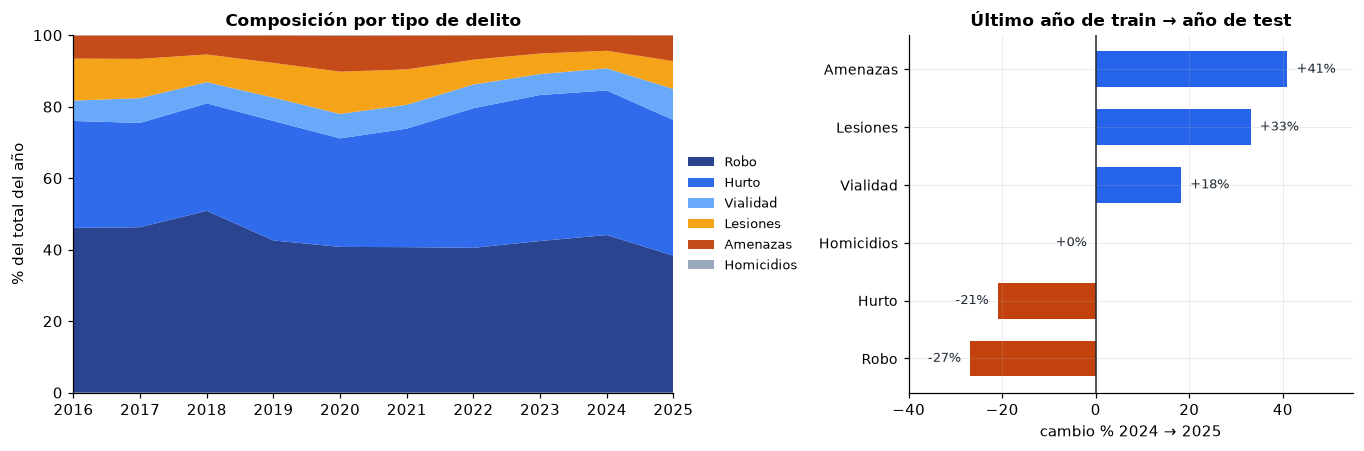

,2024,2025,cambio
tipo,,,
Amenazas,6681,9418,+41.0%
Homicidios,78,78,+0.0%
Hurto,62655,49507,-21.0%
Lesiones,7614,10134,+33.1%
Robo,68304,49938,-26.9%
Vialidad,9597,11346,+18.2%


In [4]:
shares = pd.crosstab(d.anio, d.tipo, normalize="index")
orden = shares.loc[2025].sort_values(ascending=False).index
paleta = ["#1e3a8a", "#2563eb", "#60a5fa", "#f59e0b", "#c2410c", "#94a3b8"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.2),
                               gridspec_kw={"width_ratios": [1.35, 1]})

ax1.stackplot(shares.index, *[shares[c] * 100 for c in orden],
              labels=list(orden), colors=paleta, alpha=0.95)
ax1.set_xlim(2016, 2025); ax1.set_ylim(0, 100)
ax1.set_ylabel("% del total del año"); ax1.set_title("Composición por tipo de delito")
ax1.legend(loc="center left", bbox_to_anchor=(1.005, 0.5), fontsize=8.5, frameon=False)
ax1.grid(False)

abs_ = pd.crosstab(d.anio, d.tipo)
cambio = (abs_.loc[2025] / abs_.loc[2024] - 1).sort_values() * 100
colores = [ALERTA if v < 0 else ACENTO for v in cambio.values]
ax2.barh(range(len(cambio)), cambio.values, color=colores, height=0.62)
ax2.set_yticks(range(len(cambio))); ax2.set_yticklabels(cambio.index, fontsize=9)
ax2.axvline(0, color=TINTA, lw=1)
ax2.set_xlabel("cambio % 2024 → 2025")
ax2.set_title("Último año de train → año de test")
for i, v in enumerate(cambio.values):
    ax2.annotate(f"{v:+.0f}%", (v, i), textcoords="offset points",
                 xytext=(6 if v > 0 else -6, 0), va="center",
                 ha="left" if v > 0 else "right", fontsize=8.5, color=TINTA)
ax2.set_xlim(-40, 55)
plt.tight_layout(); plt.show()

pd.DataFrame({"2024": abs_.loc[2024], "2025": abs_.loc[2025],
              "cambio": (abs_.loc[2025] / abs_.loc[2024] - 1).map("{:+.1%}".format)})

**Dos cosas, y la segunda es una salvedad que no teníamos.**

La deriva lenta: Hurto pasó del 29,9% del total en 2016 al 40,4% en 2024, mientras Lesiones
cayó de 11,7% a 4,9%. Eso ya conecta con un hallazgo previo del proyecto — **Hurto es el
único tipo donde el modelo pierde contra el promedio histórico** (−2,0%), y es justamente el
que más creció dentro del agregado. El modelo agregado está cada vez más dominado por el tipo
que mejor predice un mapa histórico, lo que ayuda a explicar por qué le gana tan poco al
baseline.

El salto abrupto: en 2025 los delitos contra la propiedad **bajan ~25%** mientras los
interpersonales **suben ~35%**, en un solo año. No es una caída pareja del nivel, es un
cambio de composición. Si es un cambio real de patrón o un cambio de criterio de registro no
se puede determinar con estos datos.

Importa porque **el año de test tiene una mezcla distinta a la de los años de entrenamiento**,
y los Módulos A y B optimizan sobre superficies de riesgo dominadas por robo y hurto.

---
## 4. Autocorrelación espacial: la premisa central, por fin medida

Todo el proyecto se apoya en que el riesgo se concentra espacialmente. Se venía respaldando
con una observación descriptiva —*"el 30% del área concentra el 58% de los delitos"*— que es
cierta pero no distingue concentración *estructurada* de concentración a secas.

**Moran's I** es el estadístico que cuantifica exactamente eso: si un hexágono con muchos
delitos tiende a estar rodeado de hexágonos con muchos delitos. Se calcula sobre la matriz
de contigüidad H3 (anillo k=1, mediana de 6 vecinos) con un test de permutación de 999
réplicas — preferible al p-valor analítico, que asume normalidad y estos conteos no la
tienen ni de cerca.

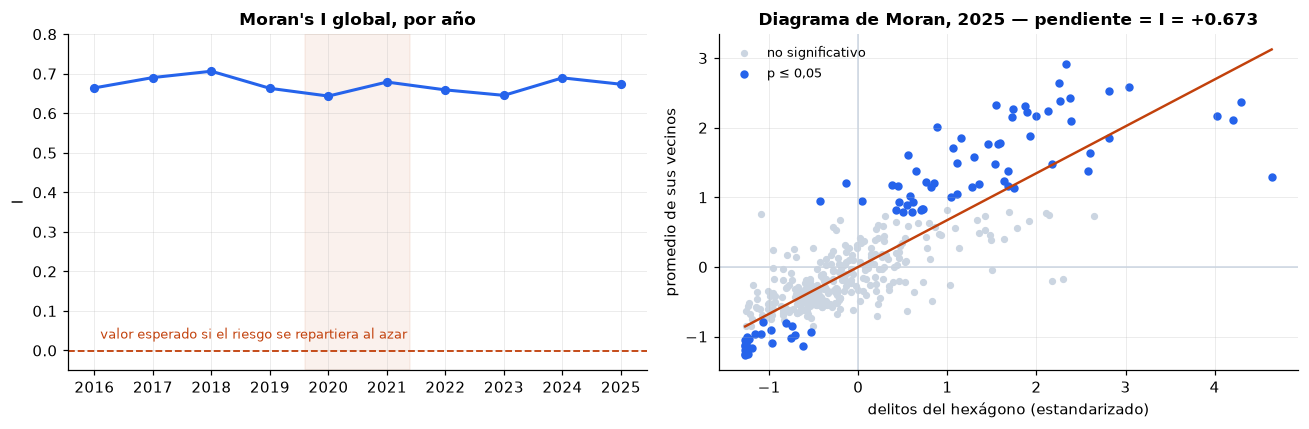

I promedio 2016-2025: +0.671  (mín +0.643 en 2020, máx +0.706 en 2018)


In [5]:
hm = pd.read_parquet(RAIZ / "data" / "features" / "hex_maestra.parquet")
hm = hm.dropna(subset=["barrio_id"]).sort_values("hex_id").reset_index(drop=True)
hexes = list(hm.hex_id)
W = matriz_vecindad(hexes)

serie_i = {}
for a in sorted(d.anio.unique()):
    v = d[d.anio == a].groupby("hex_id").size().reindex(hexes).fillna(0).to_numpy(float)
    serie_i[a] = morans_i(v, W)[0]
serie_i = pd.Series(serie_i)

v2025 = d[d.anio == 2025].groupby("hex_id").size().reindex(hexes).fillna(0).to_numpy(float)
L = morans_local(v2025, W)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(serie_i.index, serie_i.values, "-o", color=ACENTO, lw=2, ms=5)
ax1.axhline(-1 / (len(hexes) - 1), color=ALERTA, ls="--", lw=1.2)
ax1.text(2016.1, 0.03, "valor esperado si el riesgo se repartiera al azar",
         fontsize=8.5, color=ALERTA)
ax1.axvspan(2019.6, 2021.4, color=ALERTA, alpha=0.07, zorder=0)
ax1.set_ylim(-0.05, 0.8); ax1.set_xticks(serie_i.index)
ax1.set_title("Moran's I global, por año"); ax1.set_ylabel("I")

ax2.axhline(0, color="#cbd5e1", lw=1); ax2.axvline(0, color="#cbd5e1", lw=1)
sig = L.p_valor <= 0.05
ax2.scatter(L.z[~sig], L.lag[~sig], s=14, c="#cbd5e1", label="no significativo")
ax2.scatter(L.z[sig], L.lag[sig], s=20, c=ACENTO, label="p ≤ 0,05")
pend = np.polyfit(L.z, L.lag, 1)[0]
xs = np.linspace(L.z.min(), L.z.max(), 10)
ax2.plot(xs, pend * xs, color=ALERTA, lw=1.6)
ax2.set_xlabel("delitos del hexágono (estandarizado)")
ax2.set_ylabel("promedio de sus vecinos")
ax2.set_title(f"Diagrama de Moran, 2025 — pendiente = I = {pend:+.3f}")
ax2.legend(fontsize=8.5, frameon=False, loc="upper left")

plt.tight_layout(); plt.show()
print(f"I promedio 2016-2025: {serie_i.mean():+.3f}  "
      f"(mín {serie_i.min():+.3f} en {serie_i.idxmin()}, máx {serie_i.max():+.3f} en {serie_i.idxmax()})")

**I ≈ 0,67, p < 0,001 los diez años.** El riesgo no está repartido al azar: los hexágonos
peligrosos están pegados a otros hexágonos peligrosos. La pendiente del diagrama de Moran
*es* el estadístico, y se ve directamente que la nube tiene estructura.

Lo más llamativo: **la pandemia no lo movió**. En 2020 el volumen cayó a la mitad y el I
quedó en +0,643, dentro del rango de todos los demás años. Cayó cuánto pasa, no dónde.

El I global dice que hay clusters pero no dónde están. Para eso se descompone en un valor
por hexágono (LISA, Anselin 1995), con permutación condicional.

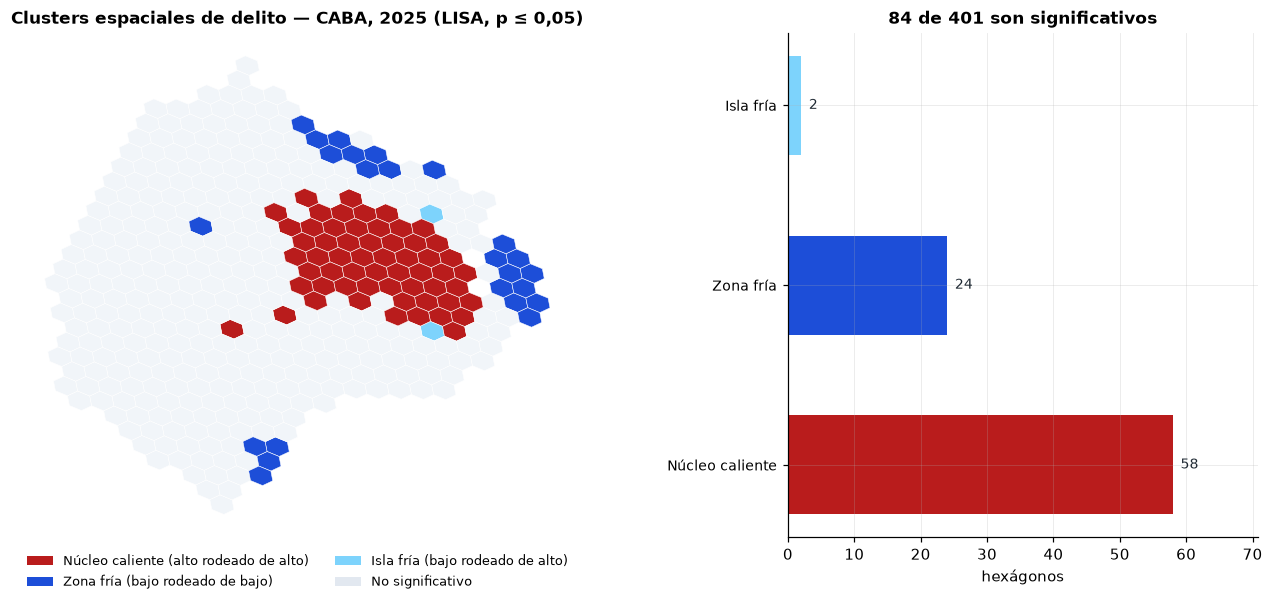

In [6]:
geoms = [wkt.loads(w) for w in hm.geometry_wkt]
polis = [np.array(g.exterior.coords) for g in geoms]

COLOR = {"alto-alto": "#b91c1c", "bajo-bajo": "#1d4ed8",
         "alto-bajo": "#f59e0b", "bajo-alto": "#7dd3fc"}
ETIQ = {"alto-alto": "Núcleo caliente (alto rodeado de alto)",
        "bajo-bajo": "Zona fría (bajo rodeado de bajo)",
        "alto-bajo": "Isla caliente (alto rodeado de bajo)",
        "bajo-alto": "Isla fría (bajo rodeado de alto)"}

sig = L.p_valor <= 0.05
caras = [COLOR[c] if s else "#f1f5f9" for c, s in zip(L.cuadrante, sig)]

fig, (axm, axb) = plt.subplots(1, 2, figsize=(12.5, 5.6),
                               gridspec_kw={"width_ratios": [1.6, 1]})
axm.add_collection(PolyCollection(polis, facecolors=caras,
                                  edgecolors="white", linewidths=0.35))
axm.autoscale_view(); axm.set_aspect("equal"); axm.axis("off"); axm.grid(False)
axm.set_title("Clusters espaciales de delito — CABA, 2025 (LISA, p ≤ 0,05)")
presentes = [c for c in COLOR if (sig & (L.cuadrante == c)).any()]
axm.legend(handles=[mpl.patches.Patch(facecolor=COLOR[c], label=ETIQ[c]) for c in presentes]
           + [mpl.patches.Patch(facecolor="#e2e8f0", label="No significativo")],
           loc="upper center", bbox_to_anchor=(0.5, -0.01), ncol=2,
           fontsize=8.5, frameon=False)

conteo = L[sig].cuadrante.value_counts().reindex(presentes).fillna(0)
axb.barh(range(len(conteo)), conteo.values,
         color=[COLOR[c] for c in conteo.index], height=0.55)
axb.set_yticks(range(len(conteo)))
axb.set_yticklabels([ETIQ[c].split(" (")[0] for c in conteo.index], fontsize=9)
axb.set_xlabel("hexágonos"); axb.set_title(f"{int(sig.sum())} de {len(L)} son significativos")
for i, v in enumerate(conteo.values):
    axb.annotate(f"{int(v)}", (v, i), textcoords="offset points", xytext=(5, 0),
                 va="center", fontsize=9, color=TINTA)
axb.set_xlim(0, conteo.max() * 1.22)
plt.tight_layout(); plt.show()

**58 hexágonos forman el núcleo caliente y 24 la periferia fría; los demás no se distinguen
del azar.** Sobre 401 hexágonos, solo 84 tienen un vecindario estadísticamente atípico.

Dos lecturas operativas. La primera: el núcleo caliente es **contiguo**, no un archipiélago
de puntos sueltos — es lo que hace que asignar patrullas por cobertura de radio tenga sentido
geométrico. La segunda: no hay ni un solo hexágono "isla caliente" significativo (alto rodeado
de bajo), lo que dice que no hay puntos calientes aislados que un esquema de cobertura por
zonas se esté perdiendo.

---
## 5. Estabilidad del ranking: el techo del proyecto

La pregunta que cierra todo: **¿el mapa de riesgo de un año predice el del siguiente?**

Es exactamente el supuesto que hace competitivo al baseline naive —un promedio histórico por
hexágono y turno— y por lo tanto define el techo contra el que compite cualquier modelo.

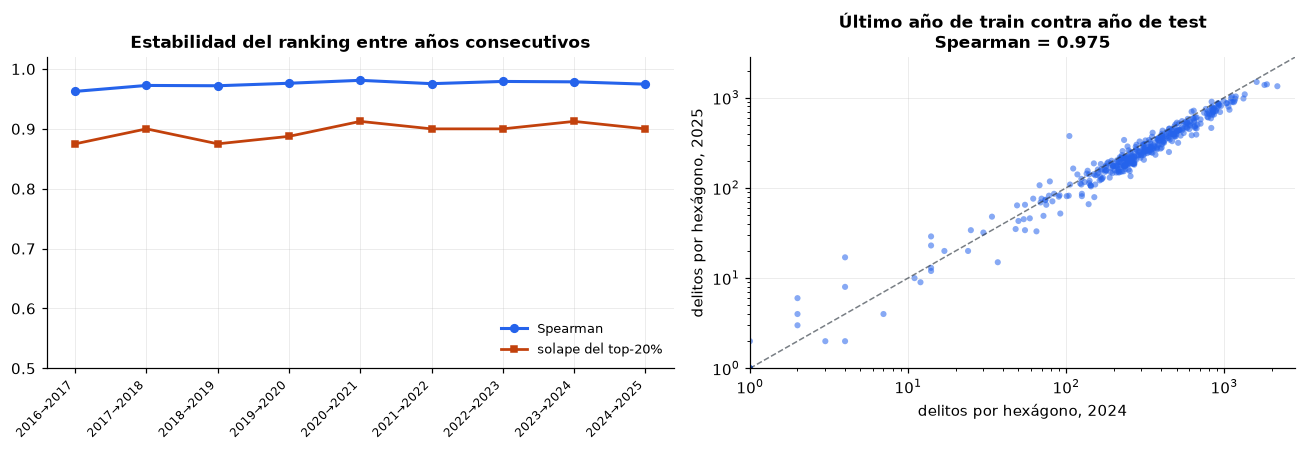

,par,spearman,solape_top20
0,2016→2017,0.963,87.5%
1,2017→2018,0.973,90.0%
2,2018→2019,0.972,87.5%
3,2019→2020,0.976,88.8%
4,2020→2021,0.981,91.2%
5,2021→2022,0.975,90.0%
6,2022→2023,0.979,90.0%
7,2023→2024,0.979,91.2%
8,2024→2025,0.975,90.0%


In [7]:
conteos = d.groupby(["anio", "hex_id"]).size().unstack(fill_value=0).reindex(columns=hexes, fill_value=0)
anios = sorted(conteos.index)

filas = []
for a, b in zip(anios, anios[1:]):
    x, y = conteos.loc[a], conteos.loc[b]
    n_top = int(round(len(x) * 0.20))
    top_a = set(x.sort_values(ascending=False).head(n_top).index)
    top_b = set(y.sort_values(ascending=False).head(n_top).index)
    filas.append({"par": f"{a}→{b}", "spearman": x.corr(y, method="spearman"),
                  "solape_top20": len(top_a & top_b) / n_top})
est = pd.DataFrame(filas)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2),
                               gridspec_kw={"width_ratios": [1.15, 1]})

ax1.plot(range(len(est)), est.spearman, "-o", color=ACENTO, lw=2, ms=5, label="Spearman")
ax1.plot(range(len(est)), est.solape_top20, "-s", color=ALERTA, lw=1.8, ms=4.5,
         label="solape del top-20%")
ax1.set_xticks(range(len(est))); ax1.set_xticklabels(est.par, rotation=45, ha="right", fontsize=8)
ax1.set_ylim(0.5, 1.02); ax1.set_title("Estabilidad del ranking entre años consecutivos")
ax1.legend(fontsize=8.5, frameon=False, loc="lower right")

x, y = conteos.loc[2024], conteos.loc[2025]
ax2.scatter(x + 1, y + 1, s=16, c=ACENTO, alpha=0.55, edgecolors="none")
lim = [1, max(x.max(), y.max()) * 1.3]
ax2.plot(lim, lim, color=TINTA, ls="--", lw=1, alpha=0.6)
ax2.set_xscale("log"); ax2.set_yscale("log"); ax2.set_xlim(lim); ax2.set_ylim(lim)
ax2.set_xlabel("delitos por hexágono, 2024"); ax2.set_ylabel("delitos por hexágono, 2025")
ax2.set_title(f"Último año de train contra año de test\nSpearman = {x.corr(y, method='spearman'):.3f}")

plt.tight_layout(); plt.show()
est.assign(spearman=est.spearman.round(3), solape_top20=est.solape_top20.map("{:.1%}".format))

**Spearman 0,983 de promedio y 91% de solape en el top-20%.** El mínimo de los nueve pares es
0,970. Incluso 2019→2020, con la cuarentena partiendo la serie al medio, da **0,989**: la
ciudad cambió de nivel sin cambiar de forma.

En el gráfico de la derecha se ve por qué: la nube se pega a la diagonal a lo largo de tres
órdenes de magnitud. Un hexágono con 800 delitos en 2024 tiene ~600 en 2025; uno con 20 tiene
~15. Bajó el nivel, se mantuvo el orden.

### Esto explica el resultado central del proyecto

El modelo LightGBM le gana al promedio histórico apenas **2,0% en MAE** y **0,8 puntos en
Recall@20%**. Eso se venía reportando como un resultado honesto pero decepcionante.

Con el Spearman a la vista, deja de ser decepcionante y pasa a ser **el resultado esperable**.
Si el mapa de un año predice el del siguiente con 0,98, un promedio histórico ya es casi
óptimo para rankear, y cualquier modelo —LightGBM, redes, lo que sea— solo puede ganar en los
márgenes. No es que el modelo sea flojo: es que **el problema de priorización espacial está
casi saturado a esta resolución**.

Coincide con los PEI de 95-99,6% medidos por tipo de delito, que dicen lo mismo desde otro
ángulo: el modelo está cerca del techo alcanzable con información perfecta.

---
## Conclusiones

| # | Hallazgo | Consecuencia |
|---|---|---|
| 1 | La pandemia no dejó cicatriz de nivel (−1,0% entre 2016-2019 y 2022-2025) | Entrenar con la serie completa es válido |
| 2 | Todo el ciclo temporal está en el turno (amplitud 1,35 contra 0,21 y 0,13) | El calendario no tiene casi nada que explicar; explica por qué el clima no aportó |
| 3 | En 2025 la propiedad baja ~25% y lo interpersonal sube ~35% | **Salvedad nueva**: el año de test tiene otra composición que los de train |
| 4 | Moran's I ≈ +0,67, p < 0,001, estable los diez años | La premisa central del proyecto queda respaldada estadísticamente |
| 5 | Spearman 0,983 año contra año, 91% de solape en el top-20% | **Define el techo**: por eso el modelo le gana tan poco al histórico |

### Qué habilita esto

El hallazgo 5 es a la vez el argumento más fuerte para probar un modelo de punto
auto-excitante (Hawkes/ETAS) —la familia canónica de crime forecasting, que modela
explícitamente el contagio *near-repeat* y es la única hipótesis que este modelo no puede
representar— y la mejor predicción de que va a aportar poco. Vale correrlo justamente por eso:
es la última pregunta abierta del lado del modelado, y responderla cierra el capítulo con
evidencia en vez de con una omisión.

El hallazgo 3 abre trabajo inmediato: hay que verificar si el salto de 2025 es un cambio de
criterio de registro antes de que las superficies de riesgo de los módulos se tomen como
definitivas.